Diabetes Research Questions:

   1. Predictive: Can we predict whether a diabetic patient's hospital encounter will result in a readmission within 30 days after discharge?
   2. Causal: Among the patients who actually received diabetes medication, how would their readmission risk have differed if they had not received it?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Reading Diabetes Dataset

In [2]:
# Keep an untouched copy of the imported dataset
df_raw = pd.read_csv("~/diabetes_data/diabetic_data.csv")

# Use a separate copy for exploratory analysis
df = df_raw.copy()
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Number of rows, and cols:

In [3]:
num_rc = df.shape
num_rc

(101766, 50)

       There are 50 columns, and 101766 rows of patient data

Column names:

In [4]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

Info (type, non-null count for each var) counts:

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

Describe (Summary stats):

In [6]:
df.describe()


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [7]:
df.describe(include="object")

/var/folders/gj/gzcs4yvn0n78llkhmth1wx6r0000gn/T/ipykernel_61642/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


Number of unique values in patient_nbr column:

In [8]:
print(df['patient_nbr'].nunique())

print(71518/101766)

71518
0.7027690977340173


Check Value Counts:

In [9]:
df.columns[df.isna().any(axis=0)].tolist()

['max_glu_serum', 'A1Cresult']

In [10]:
df.columns[df.eq('?').any()].to_list()

['race',
 'weight',
 'payer_code',
 'medical_specialty',
 'diag_1',
 'diag_2',
 'diag_3']

In [11]:
df["weight"].value_counts(normalize = True, dropna=False)

weight
?            0.968585
[75-100)     0.013128
[50-75)      0.008814
[100-125)    0.006142
[125-150)    0.001425
[25-50)      0.000953
[0-25)       0.000472
[150-175)    0.000344
[175-200)    0.000108
>200         0.000029
Name: proportion, dtype: float64

In [12]:
df["race"].value_counts(dropna=False)

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [13]:
df["payer_code"].value_counts(dropna=False)  

payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

In [14]:
df["medical_specialty"].value_counts(normalize = True, dropna=False)   

medical_specialty
?                         0.490822
InternalMedicine          0.143810
Emergency/Trauma          0.074337
Family/GeneralPractice    0.073109
Cardiology                0.052591
                            ...   
Dermatology               0.000010
SportsMedicine            0.000010
Speech                    0.000010
Perinatology              0.000010
Neurophysiology           0.000010
Name: proportion, Length: 73, dtype: float64

In [15]:
df["diag_1"].value_counts(dropna=False)

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
       ... 
833       1
391       1
690       1
10        1
V51       1
Name: count, Length: 717, dtype: int64

In [16]:
total = (df['diag_1'] == '?').sum()
print(total)

21


In [17]:
df["diag_2"].value_counts() 

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
       ... 
123       1
884       1
V60       1
843       1
927       1
Name: count, Length: 749, dtype: int64

In [18]:
total = (df['diag_2'] == '?').sum()
print(total)

358


In [19]:
df["diag_3"].value_counts() 

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
       ...  
14         1
750        1
370        1
671        1
971        1
Name: count, Length: 790, dtype: int64

In [20]:
total = (df['diag_3'] == '?').sum()
print(total)

1423


Output variable (readmitted) very unbalanced, needs to be re-coded to two vals: '<30' OR 'NO + >30'

In [21]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [22]:
df["time_in_hospital"].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

In [23]:
pd.crosstab(df["change"], df["diabetesMed"])

diabetesMed,No,Yes
change,,
Ch,0,47011
No,23403,31352


Proportion of people who were not re-admitted:

In [24]:
54864/101766

0.5391191557101586

Plots of important figures:

<Axes: xlabel='readmitted'>

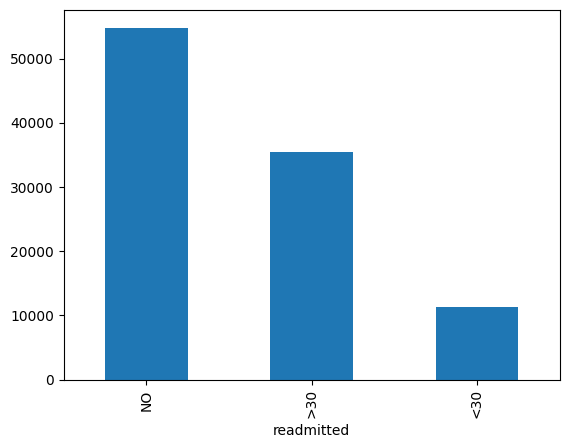

In [25]:
df["readmitted"].value_counts().plot(kind="bar")

<Axes: >

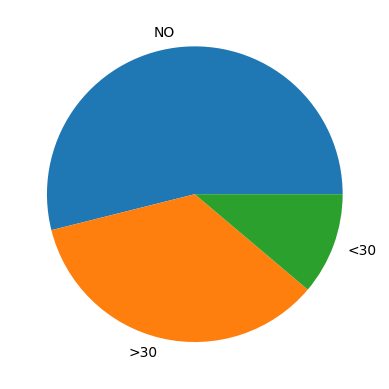

In [26]:
df["readmitted"].value_counts().plot(kind="pie")

<Axes: xlabel='age'>

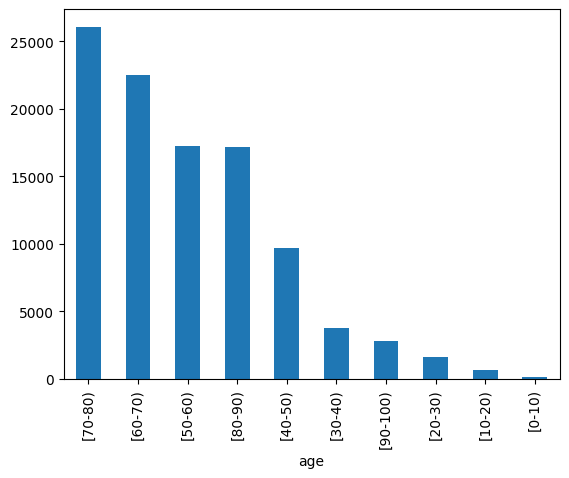

In [27]:
df["age"].value_counts().plot(kind="bar")

<Axes: xlabel='gender'>

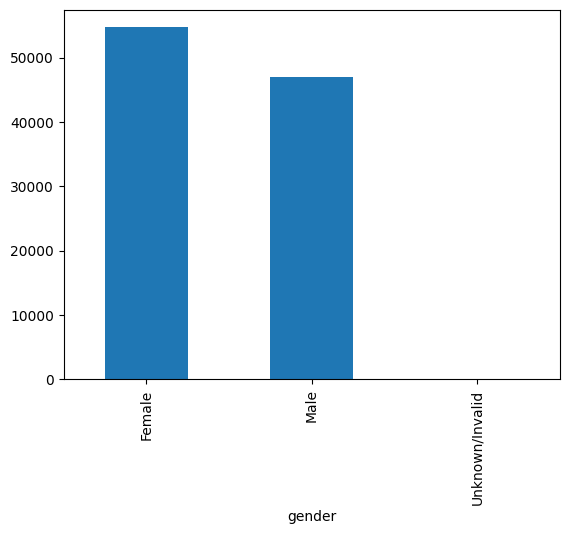

In [28]:
df["gender"].value_counts().plot(kind="bar")

Data Cleaning

The complete cleaning pipeline begins below. The original dataset remains unchanged in `df_raw`.

In [29]:
# Inspect the original outcome categories without modifying them
df_raw["readmitted"].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

The placeholder values are converted to `NaN` inside `df_clean` below, not in `df_raw`.

In [30]:
# No mutation here: cleaning is performed once in the organized pipeline below

In [31]:
df_raw["race"].value_counts(normalize=True, dropna=False)



race
Caucasian          0.747784
AfricanAmerican    0.188766
?                  0.022336
Hispanic           0.020017
Other              0.014799
Asian              0.006299
Name: proportion, dtype: float64

In [32]:
df_raw.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Organized Data-Cleaning Pipeline

The cells below create `df_clean` directly from the untouched `df_raw` DataFrame. Each cleaning choice is made explicitly and can be revisited later.

In [33]:
# Start with a separate working copy
df_clean = df_raw.copy()

# Convert the dataset's missing-value placeholder to actual NaN values
df_clean = df_clean.replace("?", np.nan)

print(f"Starting shape: {df_clean.shape}")

Starting shape: (101766, 50)


### 1. Summarize missing data

Missingness is examined before columns or rows are removed.

In [34]:
missing_summary = (
    df_clean.isna().sum()
    .to_frame(name="missing_count")
    .assign(missing_percent=lambda x: (100 * x["missing_count"] / len(df_clean)).round(2))
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

missing_summary

,missing_count,missing_percent
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


### 2. Remove unusable columns

`weight` is removed because almost all of its values are missing. `payer_code` is both substantially incomplete and primarily administrative. `examide` and `citoglipton` have no variation, so they cannot help distinguish outcomes.

In [35]:
columns_to_drop = ["weight", "payer_code", "examide", "citoglipton"]
df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.shape

(101766, 46)

### 3. Handle missing categorical values

The remaining missing values occur in categorical fields. They are retained as an explicit `Unknown` category rather than imputing a potentially incorrect race, specialty, or diagnosis.

In [36]:
categorical_missing_columns = [
    "race", "medical_specialty", "diag_1", "diag_2", "diag_3"
]

df_clean[categorical_missing_columns] = (
    df_clean[categorical_missing_columns].fillna("Unknown")
)

df_clean[categorical_missing_columns].isna().sum()

race                 0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
dtype: int64

### 4. Remove records ineligible for ordinary readmission

Encounters ending in death or discharge to hospice are excluded because these patients are not eligible for an ordinary subsequent hospital readmission. The listed codes correspond to hospice or expired dispositions in this dataset.

In [37]:
ineligible_discharge_codes = [11, 13, 14, 19, 20, 21]
rows_before = len(df_clean)

df_clean = df_clean.loc[
    ~df_clean["discharge_disposition_id"].isin(ineligible_discharge_codes)
].copy()

print(f"Removed {rows_before - len(df_clean):,} ineligible encounters.")

Removed 2,423 ineligible encounters.


### 5. Handle invalid gender values and duplicates

In [38]:
# There are only a few records with an invalid gender label
df_clean = df_clean.loc[df_clean["gender"] != "Unknown/Invalid"].copy()

print("Exact duplicate rows:", df_clean.duplicated().sum())
print("Duplicate encounter IDs:", df_clean["encounter_id"].duplicated().sum())

# encounter_id should uniquely identify an encounter
df_clean = df_clean.drop_duplicates(subset="encounter_id")

Exact duplicate rows: 0
Duplicate encounter IDs: 0


### 6. Create the binary outcome

`readmitted_30d` equals 1 when the patient was readmitted within 30 days and 0 otherwise. The original `readmitted` column is retained for reference.

In [39]:
df_clean["readmitted_30d"] = (df_clean["readmitted"] == "<30").astype("int8")

df_clean["readmitted_30d"].value_counts().to_frame("count").assign(
    proportion=df_clean["readmitted_30d"].value_counts(normalize=True).round(4)
)

,count,proportion
readmitted_30d,,
0,88026,0.8861
1,11314,0.1139


### 7. Treat numeric ID codes as categorical variables

These columns contain category codes rather than continuous measurements. Converting them to `category` prevents their numeric values from being interpreted as quantities during exploration.

In [40]:
coded_categorical_columns = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
]

df_clean[coded_categorical_columns] = (
    df_clean[coded_categorical_columns].astype("category")
)

### 8. Validate the cleaned dataset

Repeated patient numbers are intentionally retained because the unit of analysis is the hospital encounter. During modeling, the train/test split should be grouped by `patient_nbr` to prevent the same patient from appearing in both sets.

In [41]:
cleaning_checks = pd.Series({
    "rows": len(df_clean),
    "columns": df_clean.shape[1],
    "unique_encounters": df_clean["encounter_id"].nunique(),
    "unique_patients": df_clean["patient_nbr"].nunique(),
    "remaining_missing_values": int(df_clean.isna().sum().sum()),
    "duplicate_encounter_ids": int(df_clean["encounter_id"].duplicated().sum()),
})

cleaning_checks

rows                         99340
columns                         47
unique_encounters            99340
unique_patients              69987
remaining_missing_values    176694
duplicate_encounter_ids          0
dtype: int64

In [42]:
df_clean.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


# 9. Exploratory Data Analysis

This section examines the distributions of important variables and their relationship with 30-day readmission.

The goal is to identify potential predictors and better understand the characteristics of the cleaned dataset before feature engineering and modeling.

### 9.1 Summary of Numeric Variables

First examine the distributions of the main numeric variables.

In [43]:
numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,99340.0,4.379364,2.968393,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,99340.0,42.907198,19.609887,1.0,31.0,44.0,57.0,132.0
num_procedures,99340.0,1.334196,1.702770,0.0,0.0,1.0,2.0,6.0
num_medications,99340.0,15.979052,8.094931,1.0,10.0,15.0,20.0,81.0
number_outpatient,99340.0,0.369257,1.265160,0.0,0.0,0.0,0.0,42.0
number_emergency,99340.0,0.198450,0.937747,0.0,0.0,0.0,0.0,76.0
number_inpatient,99340.0,0.630954,1.260443,0.0,0.0,0.0,1.0,21.0


### 9.2 Numeric Variable Distributions

Visualize the distributions to identify skewness and potential outliers.

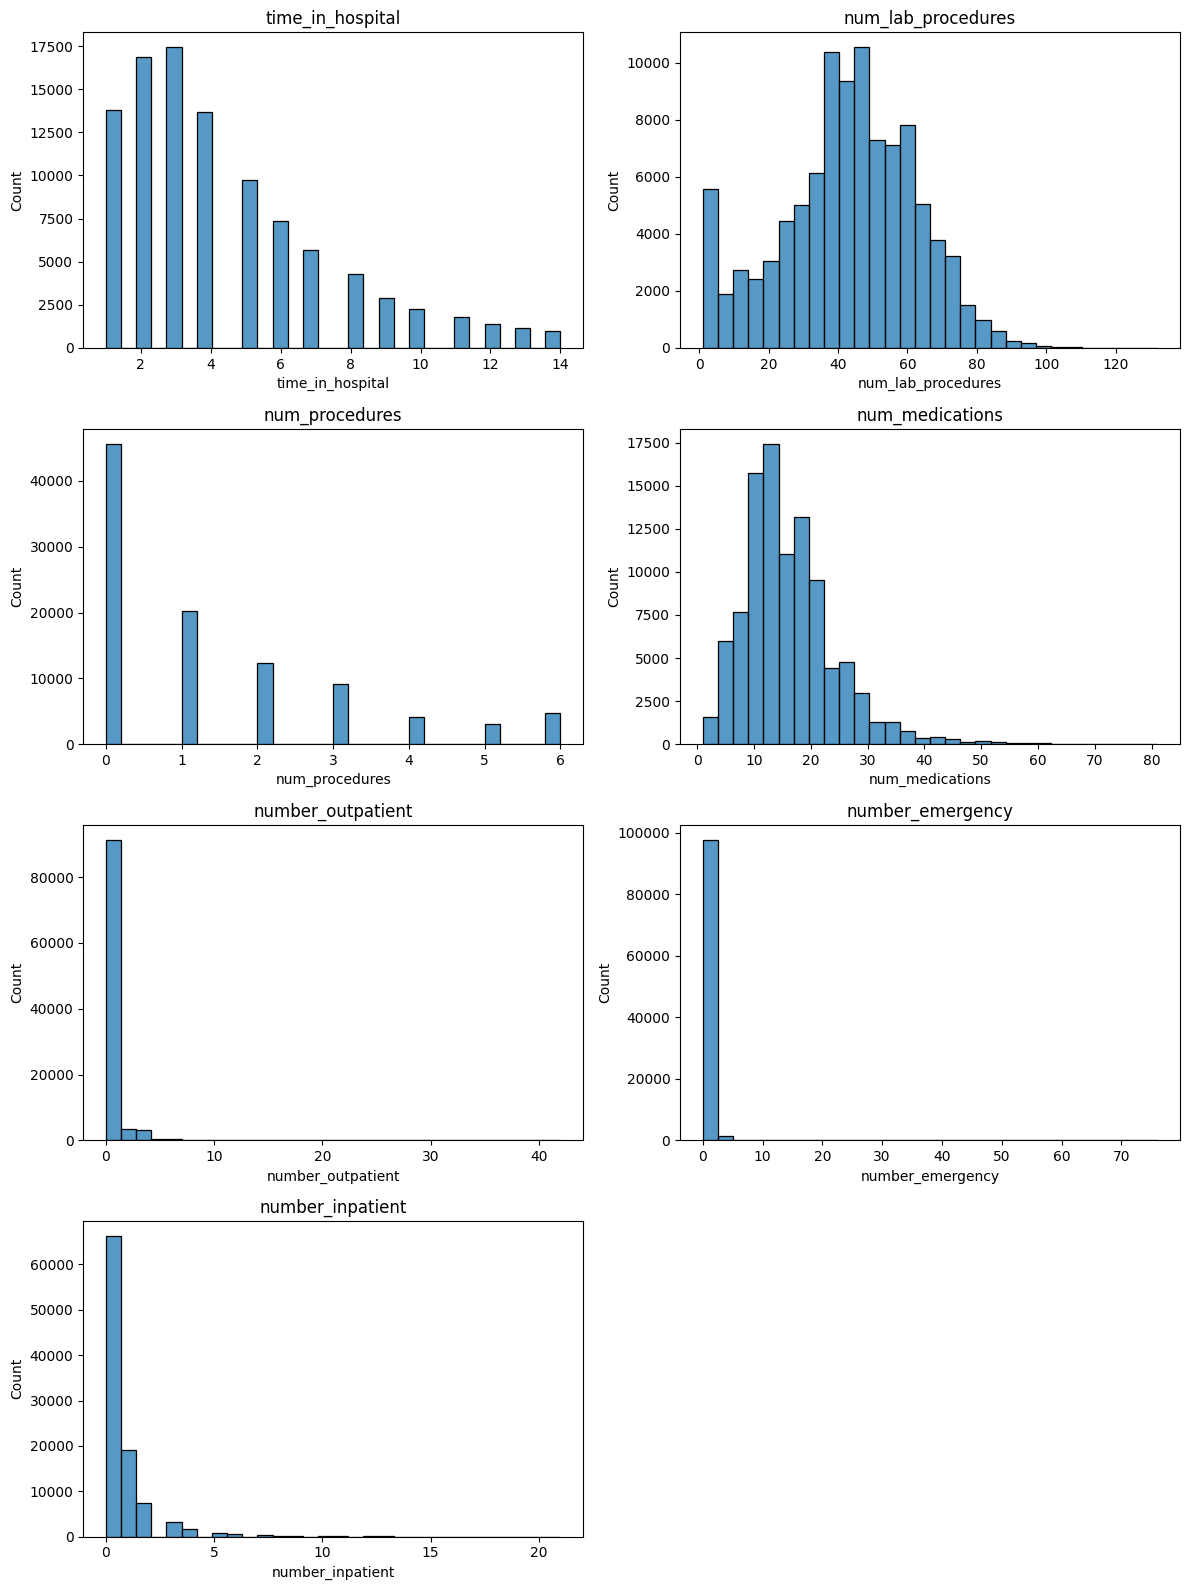

In [44]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.histplot(df_clean[column], bins=30, ax=ax)
    ax.set_title(column)

for ax in axes[len(numeric_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

### 9.3 Numeric Features vs Readmission

Compare the distributions of numeric variables between patients who were and were not readmitted within 30 days.

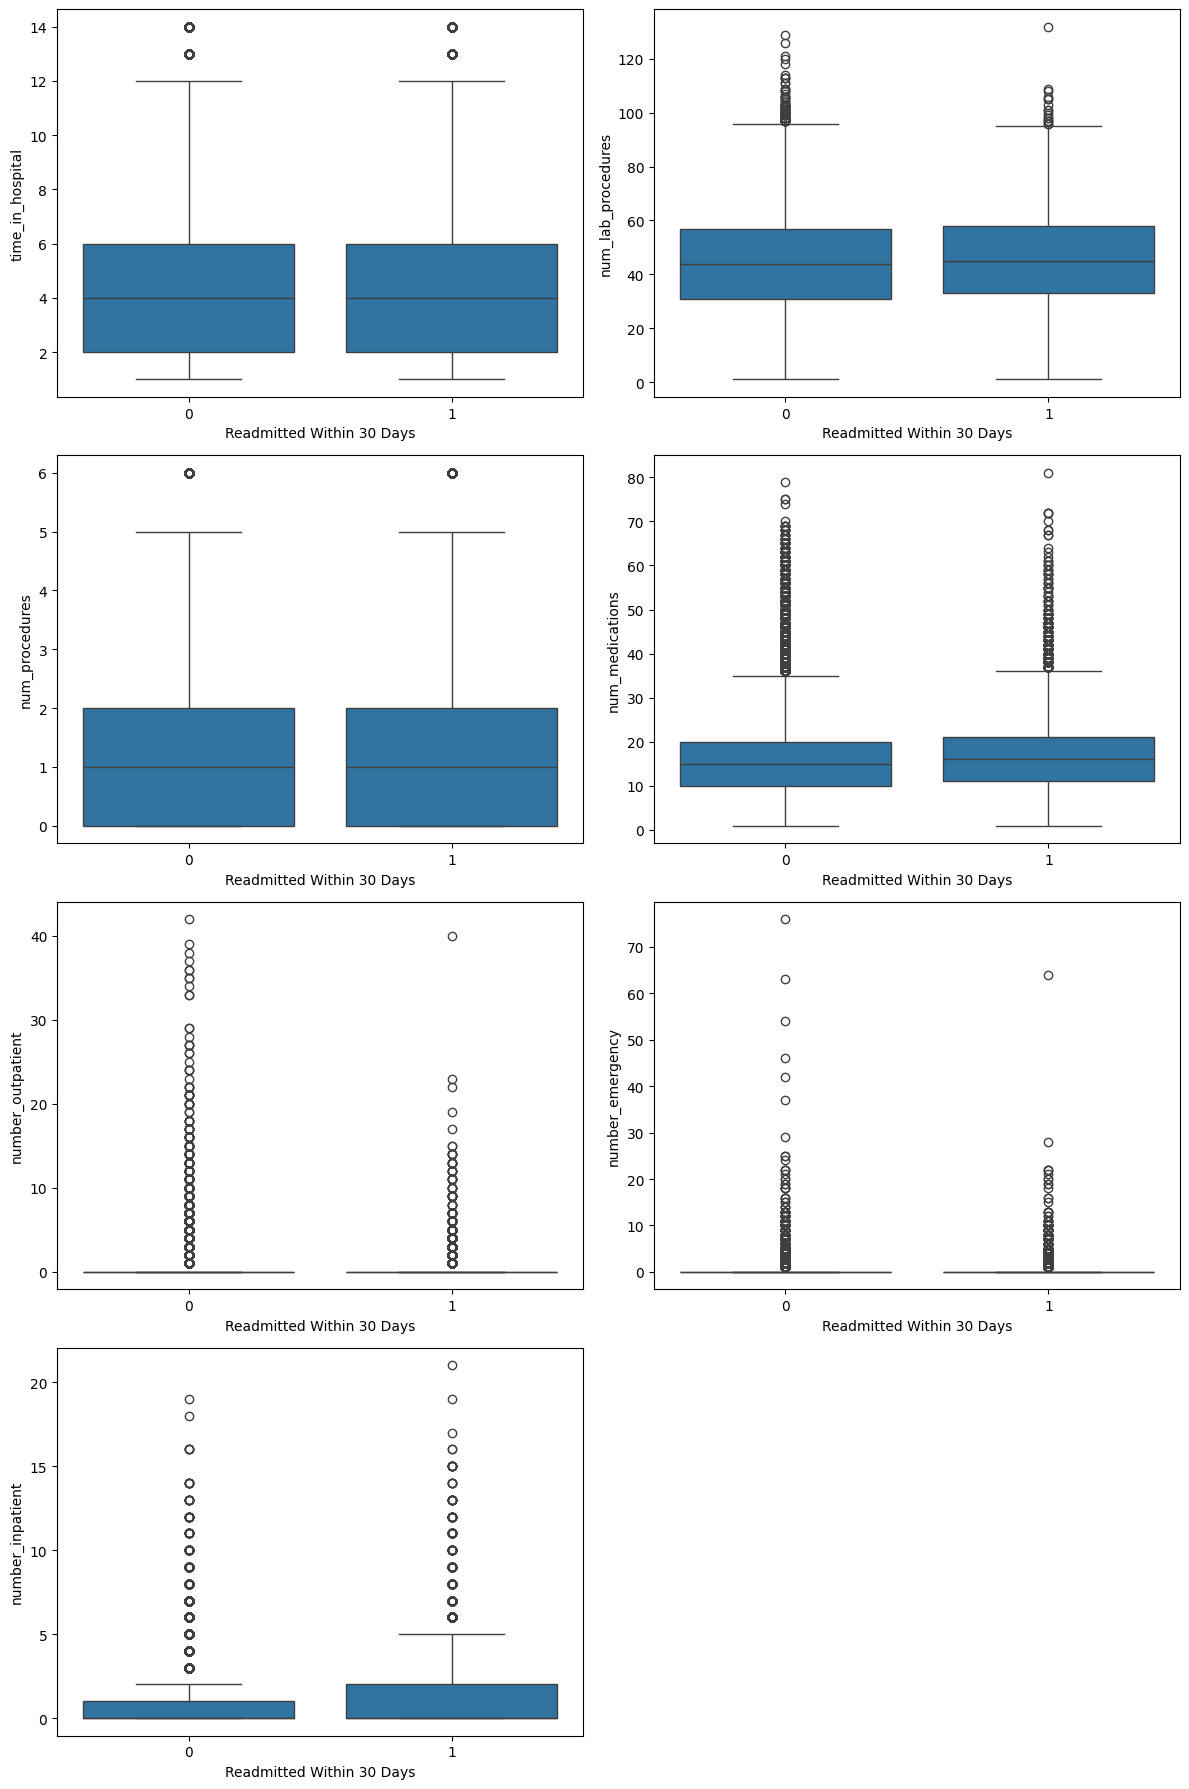

In [45]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(data=df_clean, x="readmitted_30d", y=column, ax=ax)
    ax.set_xlabel("Readmitted Within 30 Days")
    ax.set_ylabel(column)

for ax in axes[len(numeric_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

### 9.4 Categorical Features vs Readmission

Compare readmission rates across selected categorical variables.

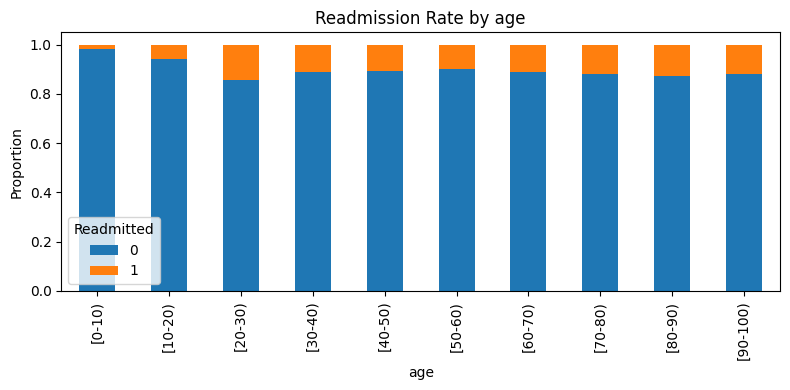

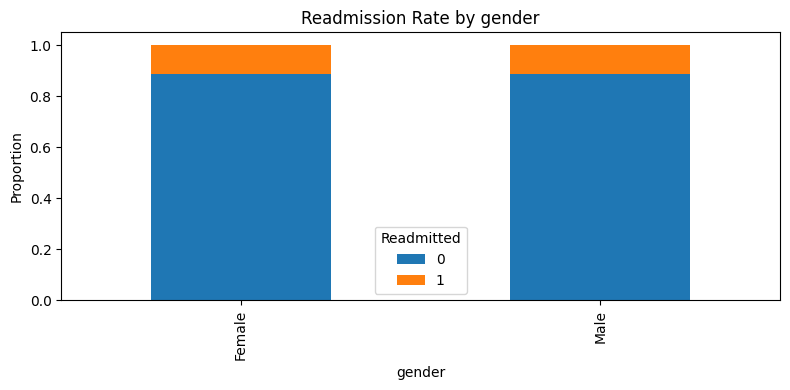

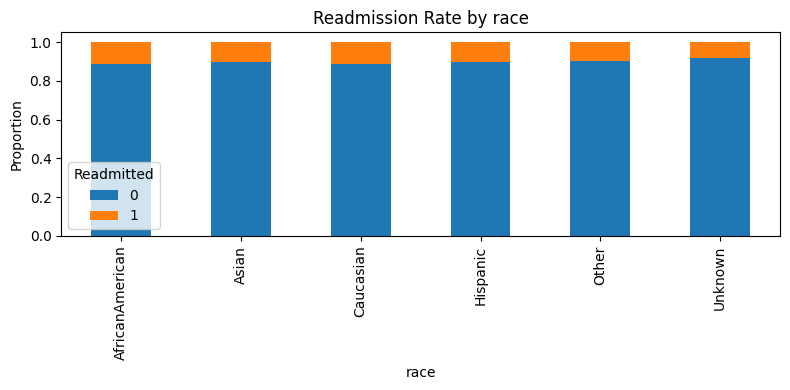

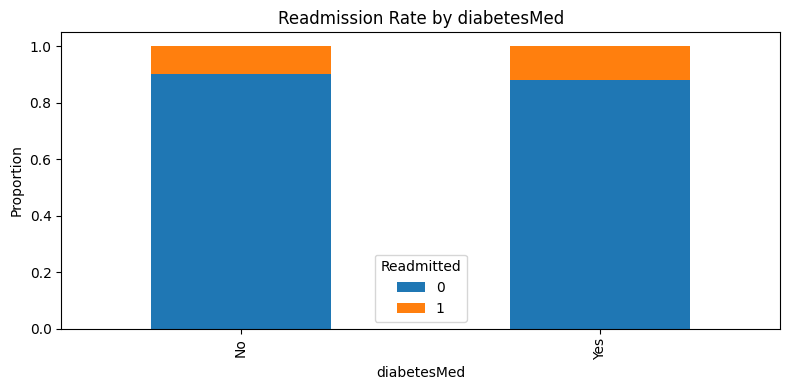

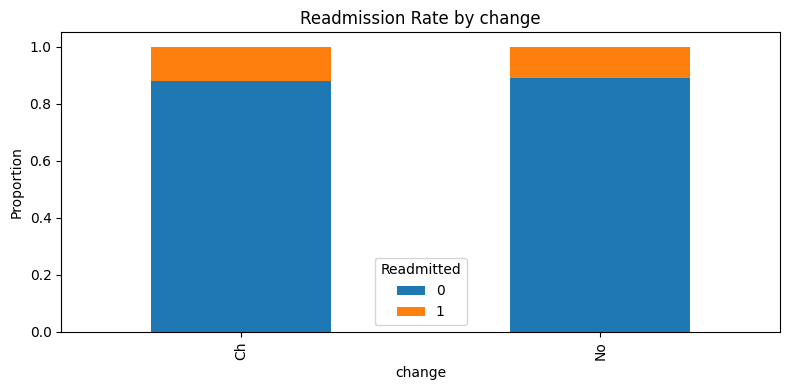

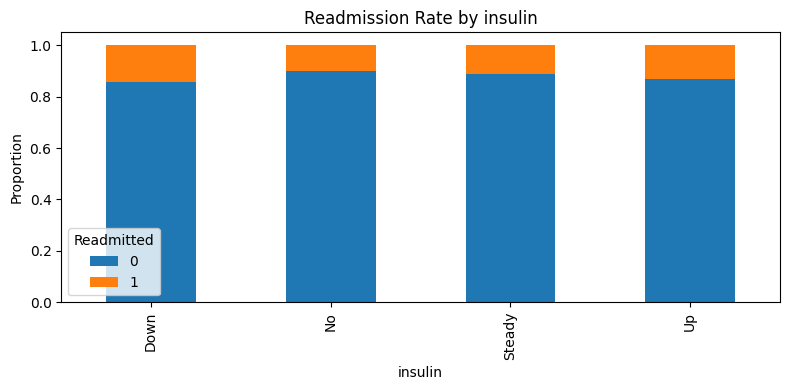

In [46]:
categorical_columns = [
    "age",
    "gender",
    "race",
    "diabetesMed",
    "change",
    "insulin"
]

for column in categorical_columns:
    proportions = pd.crosstab(
        df_clean[column],
        df_clean["readmitted_30d"],
        normalize="index"
    )

    proportions.plot(kind="bar", stacked=True, figsize=(8, 4))

    plt.title(f"Readmission Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Proportion")
    plt.legend(title="Readmitted")
    plt.tight_layout()
    plt.show()

### 9.5 Correlation Among Numeric Variables

Examine correlations among numeric variables.

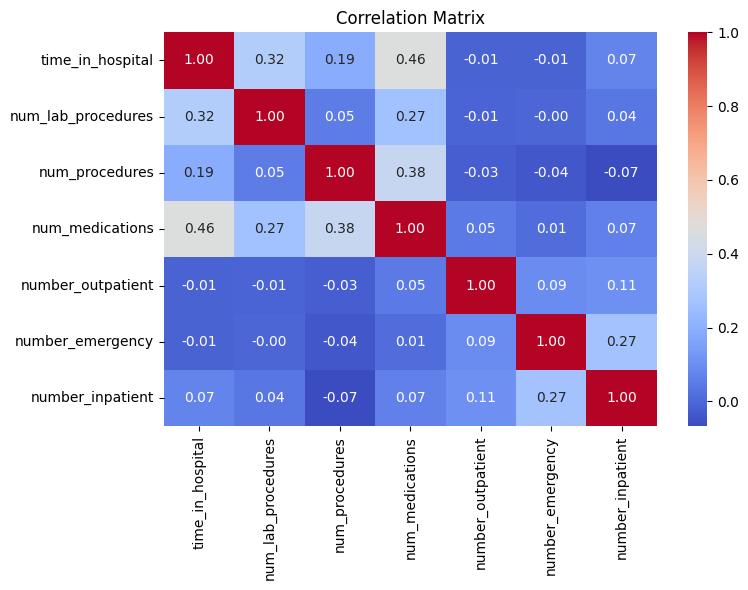

In [47]:
corr = df_clean[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 9.6 Patient Encounter Counts

Some patients appear multiple times because each row represents a hospital encounter.

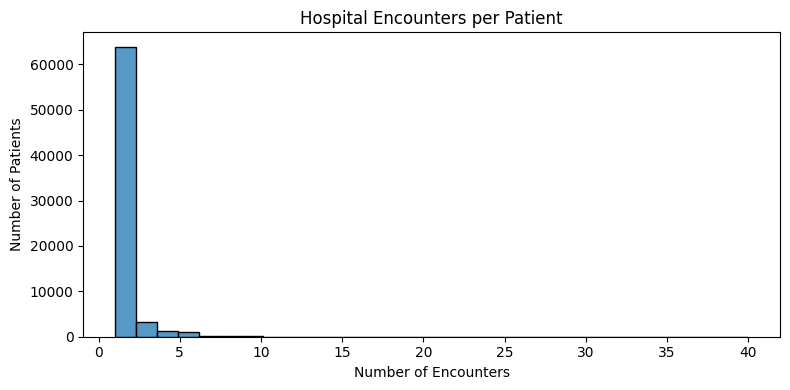

In [48]:
encounters_per_patient = df_clean["patient_nbr"].value_counts()

plt.figure(figsize=(8, 4))

sns.histplot(encounters_per_patient, bins=30)

plt.xlabel("Number of Encounters")
plt.ylabel("Number of Patients")
plt.title("Hospital Encounters per Patient")

plt.tight_layout()
plt.show()

### 9.7 Readmission Rates for Key Variables

Summarize readmission rates for selected categorical variables.

In [49]:
for column in categorical_columns:
    summary = (
        df_clean
        .groupby(column)["readmitted_30d"]
        .mean()
        .sort_values(ascending=False)
        .rename("Readmission Rate")
    )

    display(summary)

age
[20-30)     0.143117
[80-90)     0.125654
[70-80)     0.120573
[90-100)    0.118965
[60-70)     0.113020
[30-40)     0.112646
[40-50)     0.106589
[50-60)     0.097714
[10-20)     0.057971
[0-10)      0.018750
Name: Readmission Rate, dtype: float64

gender
Female    0.114641
Male      0.113019
Name: Readmission Rate, dtype: float64

race
Caucasian          0.115279
AfricanAmerican    0.114479
Hispanic           0.105107
Asian              0.103503
Other              0.097893
Unknown            0.084229
Name: Readmission Rate, dtype: float64

diabetesMed
Yes    0.118370
No     0.098705
Name: Readmission Rate, dtype: float64

change
Ch    0.120230
No    0.108399
Name: Readmission Rate, dtype: float64

insulin
Down      0.142173
Up        0.133339
Steady    0.113738
No        0.102122
Name: Readmission Rate, dtype: float64

EDA Summary:

- Previous healthcare utilization variables are highly right-skewed.
- number_inpatient shows the clearest difference between readmitted and non-readmitted patients.
- Most numeric variables exhibit only weak to moderate correlations, indicating limited multicollinearity.
- Several demographic and treatment-related variables show differences in readmission rates and will be retained for predictive modeling.

In [50]:
df_clean.to_csv("diabetes_clean.csv", index=False)